# Exploratory Data Analysis (EDA)
## Industrialization vs Decarbonization: EU-6 Panel Analysis (2010-2024)

**Phase 3, Milestone 3.1: Statistical Analysis (Part 1)**

This notebook provides comprehensive exploratory analysis of the harmonized panel dataset.

### Objectives:
1. Understand the structure and distribution of key variables
2. Identify temporal patterns and country-level heterogeneity
3. Examine correlations between carbon pricing, industrial output, and emissions
4. Prepare insights for formal hypothesis testing

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
%matplotlib inline


COUNTRY_COLORS = {
    'Germany': '#1f77b4',
    'France': '#ff7f0e',
    'Italy': '#2ca02c',
    'Spain': '#d62728',
    'Netherlands': '#9467bd',
    'Poland': '#8c564b'
}

# Output directory
OUTPUT_DIR = Path('../../output/figures')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## 1. Load and Inspect Data

In [5]:
DATA_PATH = Path('../../data/processed/panel_dataset.csv')
df = pd.read_csv(DATA_PATH)
df.head(10)

,country_code,country,year,gva_industry_meur,gva_manufacturing_meur,gva_total_meur,industry_share_pct,manufacturing_share_pct,industry_yoy_growth_pct,ppi_index_2015,...,covid_period,energy_crisis,ets_phase_3,ets_phase_4,carbon_price_lag1,carbon_price_lag2,ln_gva_industry,ln_gva_total,ln_carbon_price,ln_emissions
0,DE,Germany,2010,617890.8,544972.8,2534283.9,24.38,21.50,NaN,92.3,...,0,0,0,0,NaN,NaN,13.3341,14.7454,2.6617,6.8469
1,DE,Germany,2011,650943.3,594104.7,2629245.3,24.76,22.60,5.349246,97.5,...,0,0,0,0,14.32,NaN,13.3862,14.7822,2.6261,6.8330
2,DE,Germany,2012,653401.7,583777.2,2642528.6,24.73,22.09,0.377667,99.2,...,0,0,0,0,13.82,14.32,13.3899,14.7872,1.9933,6.8330
3,DE,Germany,2013,645616.6,583471.7,2654681.4,24.32,21.98,-1.191472,99.0,...,0,0,1,0,7.34,13.82,13.3780,14.7918,1.4951,6.8544
4,DE,Germany,2014,675869.3,615920.7,2714315.0,24.90,22.69,4.685862,98.5,...,0,0,1,0,4.46,7.34,13.4238,14.8141,1.7851,6.8079
5,DE,Germany,2015,684747.0,621665.0,2753317.0,24.87,22.58,1.313523,100.0,...,0,0,1,0,5.96,4.46,13.4368,14.8283,2.0386,6.8090
6,DE,Germany,2016,711585.1,645864.3,2816907.3,25.26,22.93,3.919418,97.8,...,0,0,1,0,7.68,5.96,13.4753,14.8512,1.6771,6.8123
7,DE,Germany,2017,736715.9,667252.5,2898585.4,25.42,23.02,3.531665,100.3,...,0,0,1,0,5.35,7.68,13.5100,14.8797,1.7630,6.8068
8,DE,Germany,2018,744159.6,675624.5,2933913.3,25.36,23.03,1.010389,103.1,...,0,0,1,0,5.83,5.35,13.5200,14.8918,2.7619,6.7627
9,DE,Germany,2019,737467.1,666152.6,2953979.6,24.97,22.55,-0.899337,103.8,...,0,0,1,0,15.83,5.83,13.5110,14.8987,3.2125,6.6958


### Data types and missing values

In [6]:
print("\nVariable Information:")
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(1)
})
info_df[info_df['Missing'] > 0]


Variable Information:


,Type,Non-Null,Missing,Missing %
industry_yoy_growth_pct,float64,84,6,6.7
ppi_inflation_pct,float64,84,6,6.7
emissions_yoy_pct,float64,84,6,6.7
industry_growth_pct,float64,84,6,6.7
gdp_growth_pct,float64,84,6,6.7
decoupling_index,float64,84,6,6.7
carbon_price_lag1,float64,84,6,6.7
carbon_price_lag2,float64,78,12,13.3


## 2. Descriptive Statistics

In [7]:
# Key variables for analysis
key_vars = [
    'gva_industry_meur',
    'gva_industry_real_meur',
    'carbon_price_eur_tonne',
    'total_ghg_mt_co2eq',
    'carbon_intensity_t_per_meur',
    'carbon_cost_burden_pct',
    'free_allocation_ratio_pct',
    'industry_share_pct'
]

print("DESCRIPTIVE STATISTICS - KEY VARIABLES")
print("="*70)
df[key_vars].describe().round(2)

DESCRIPTIVE STATISTICS - KEY VARIABLES


,gva_industry_meur,gva_industry_real_meur,carbon_price_eur_tonne,total_ghg_mt_co2eq,carbon_intensity_t_per_meur,carbon_cost_burden_pct,free_allocation_ratio_pct,industry_share_pct
count,90.00,90.00,90.00,90.00,90.00,90.00,90.00,90.00
mean,269758.20,254535.74,27.40,432.80,1970.40,0.57,79.02,18.87
std,204035.44,195614.66,27.44,209.43,869.64,0.89,15.84,4.60
min,84240.00,72762.02,4.46,144.00,948.27,0.00,50.00,11.78
25%,112281.20,101630.84,5.96,324.25,1426.06,0.04,68.00,15.28
50%,212126.90,188456.74,14.32,396.00,1709.97,0.12,79.00,17.37
75%,286408.38,278109.70,53.31,464.00,2036.98,0.89,89.50,24.24
max,744159.60,734512.36,83.66,948.00,4748.34,4.33,110.00,26.51


In [8]:
# Statistics by country
print("\nMEAN VALUES BY COUNTRY (2010-2024)")
print("="*70)
country_stats = df.groupby('country')[key_vars].mean().round(2)
country_stats


MEAN VALUES BY COUNTRY (2010-2024)


,gva_industry_meur,gva_industry_real_meur,carbon_price_eur_tonne,total_ghg_mt_co2eq,carbon_intensity_t_per_meur,carbon_cost_burden_pct,free_allocation_ratio_pct,industry_share_pct
country,,,,,,,,
France,269551.13,257650.95,27.4,447.33,1661.67,0.28,80.27,13.46
Germany,692436.48,653537.27,27.4,841.33,1222.13,0.46,76.40,24.58
Italy,284911.12,269338.24,27.4,423.47,1489.84,0.43,77.13,18.60
Netherlands,101860.54,94689.83,27.4,181.27,1792.69,0.56,76.87,15.42
Poland,105855.48,97752.47,27.4,387.00,3721.11,1.17,83.67,25.23
Spain,163934.47,154245.70,27.4,316.40,1934.98,0.52,79.80,15.93


In [9]:
# Statistics by ETS Phase
print("\nMEAN VALUES BY ETS PHASE")
print("="*70)
phase_mapping = {2: 'Phase 2 (2010-2012)', 3: 'Phase 3 (2013-2020)', 4: 'Phase 4 (2021-2024)'}
df['ets_phase_label'] = df['ets_phase'].map(phase_mapping)
phase_stats = df.groupby('ets_phase_label')[key_vars].mean().round(2)
phase_stats


MEAN VALUES BY ETS PHASE


,gva_industry_meur,gva_industry_real_meur,carbon_price_eur_tonne,total_ghg_mt_co2eq,carbon_intensity_t_per_meur,carbon_cost_burden_pct,free_allocation_ratio_pct,industry_share_pct
ets_phase_label,,,,,,,,
Phase 2 (2010-2012),255795.07,266920.66,11.83,476.94,2296.31,0.00,101.94,19.30
Phase 3 (2013-2020),270189.96,269510.90,11.84,441.02,2005.39,0.19,80.35,19.09
Phase 4 (2021-2024),279367.04,215296.73,70.20,383.25,1656.00,1.74,59.17,18.12


In [10]:
# Statistics by price regime
print("\nMEAN VALUES BY CARBON PRICE REGIME")
print("="*70)
regime_stats = df.groupby('price_regime')[[
    'carbon_price_eur_tonne', 'gva_industry_real_meur', 
    'total_ghg_mt_co2eq', 'carbon_cost_burden_pct'
]].agg(['mean', 'std']).round(2)
regime_stats


MEAN VALUES BY CARBON PRICE REGIME


carbon_price_eur_tonne        gva_industry_real_meur  \
                                  mean    std                   mean   
price_regime                                                           
High (>€50)                      70.20  12.65              215296.73   
Low (<€10)                        6.10   1.12              267659.15   
Medium (€10-50)                  18.71   5.10              270178.86   

                           total_ghg_mt_co2eq         carbon_cost_burden_pct  \
                       std               mean     std                   mean   
price_regime                                                                   
High (>€50)      168487.66             383.25  173.00                   1.74   
Low (<€10)       206269.38             456.44  227.92                   0.06   
Medium (€10-50)  204520.16             444.07  212.89                   0.24   

                       
                  std  
price_regime           
High (>€50)      0.98  
Low (<€10)       0.04  
Medium (€10-50)  0.26

## 3. Temporal Analysis: Key Trends Over Time

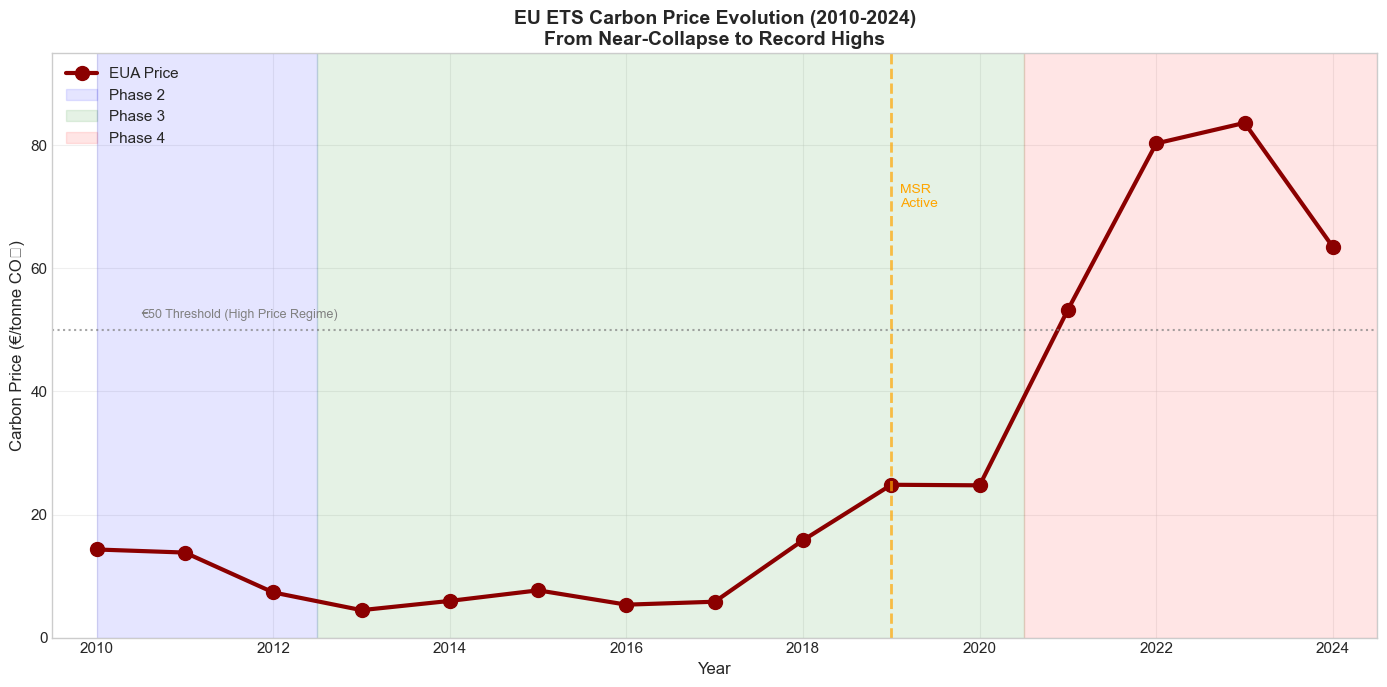


✓ Saved: ../../output/figures/fig1_carbon_price_evolution.png


In [11]:
# Figure 1: Carbon Price Evolution with Policy Milestones
fig, ax = plt.subplots(figsize=(14, 7))

price_series = df.drop_duplicates('year')[['year', 'carbon_price_eur_tonne']].sort_values('year')
ax.plot(price_series['year'], price_series['carbon_price_eur_tonne'], 
        marker='o', linewidth=3, markersize=10, color='darkred', label='EUA Price')

# Shade ETS phases
ax.axvspan(2010, 2012.5, alpha=0.1, color='blue', label='Phase 2')
ax.axvspan(2012.5, 2020.5, alpha=0.1, color='green', label='Phase 3')
ax.axvspan(2020.5, 2024.5, alpha=0.1, color='red', label='Phase 4')

# Policy milestones
ax.axvline(x=2019, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax.text(2019.1, 70, 'MSR\nActive', fontsize=10, color='orange')

ax.axhline(y=50, color='gray', linestyle=':', alpha=0.7)
ax.text(2010.5, 52, '€50 Threshold (High Price Regime)', fontsize=9, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Carbon Price (€/tonne CO₂)', fontsize=12)
ax.set_title('EU ETS Carbon Price Evolution (2010-2024)\nFrom Near-Collapse to Record Highs', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlim(2009.5, 2024.5)
ax.set_ylim(0, 95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_carbon_price_evolution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig1_carbon_price_evolution.png'}")

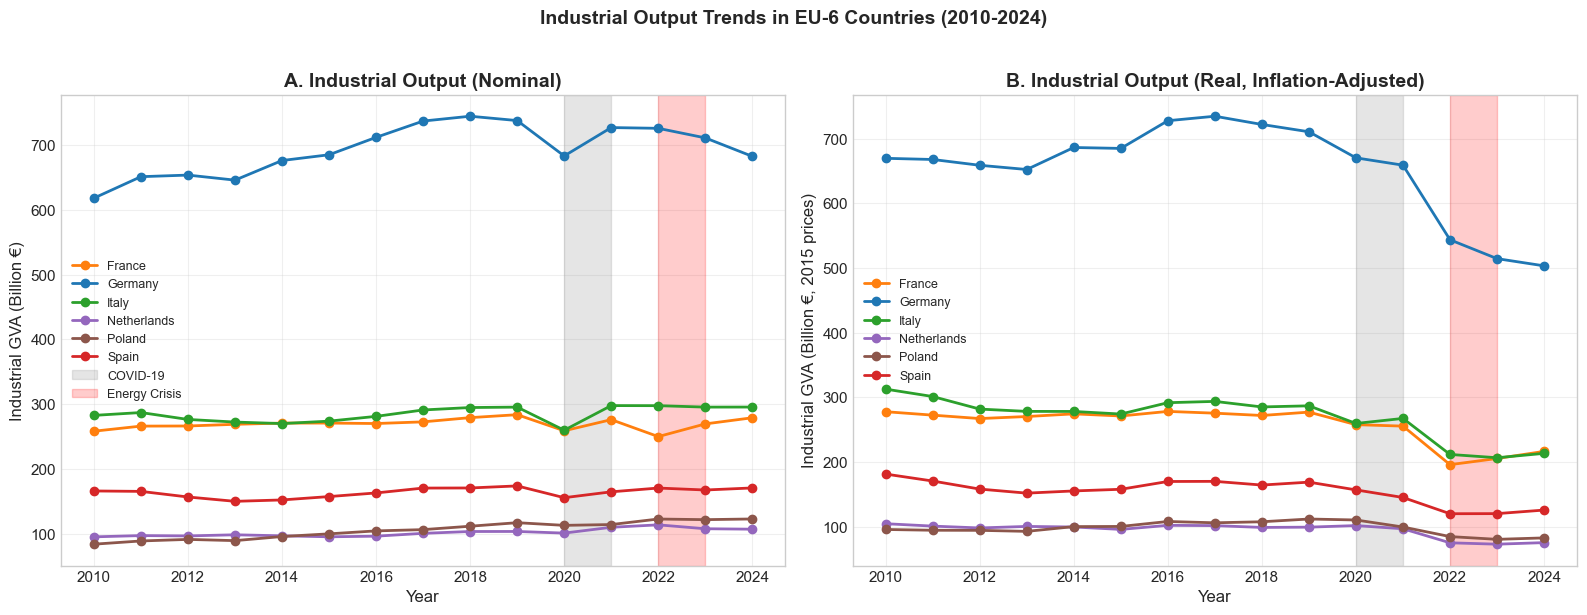


✓ Saved: ../../output/figures/fig2_industrial_output_trends.png


In [12]:
# Figure 2: Industrial Output (GVA) by Country
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Nominal GVA
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[0].plot(data['year'], data['gva_industry_meur']/1000, 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[0].axvspan(2020, 2021, alpha=0.2, color='gray', label='COVID-19')
axes[0].axvspan(2022, 2023, alpha=0.2, color='red', label='Energy Crisis')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Industrial GVA (Billion €)')
axes[0].set_title('A. Industrial Output (Nominal)', fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel B: Real GVA (2015 prices)
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[1].plot(data['year'], data['gva_industry_real_meur']/1000, 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[1].axvspan(2020, 2021, alpha=0.2, color='gray')
axes[1].axvspan(2022, 2023, alpha=0.2, color='red')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Industrial GVA (Billion €, 2015 prices)')
axes[1].set_title('B. Industrial Output (Real, Inflation-Adjusted)', fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Industrial Output Trends in EU-6 Countries (2010-2024)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_industrial_output_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig2_industrial_output_trends.png'}")

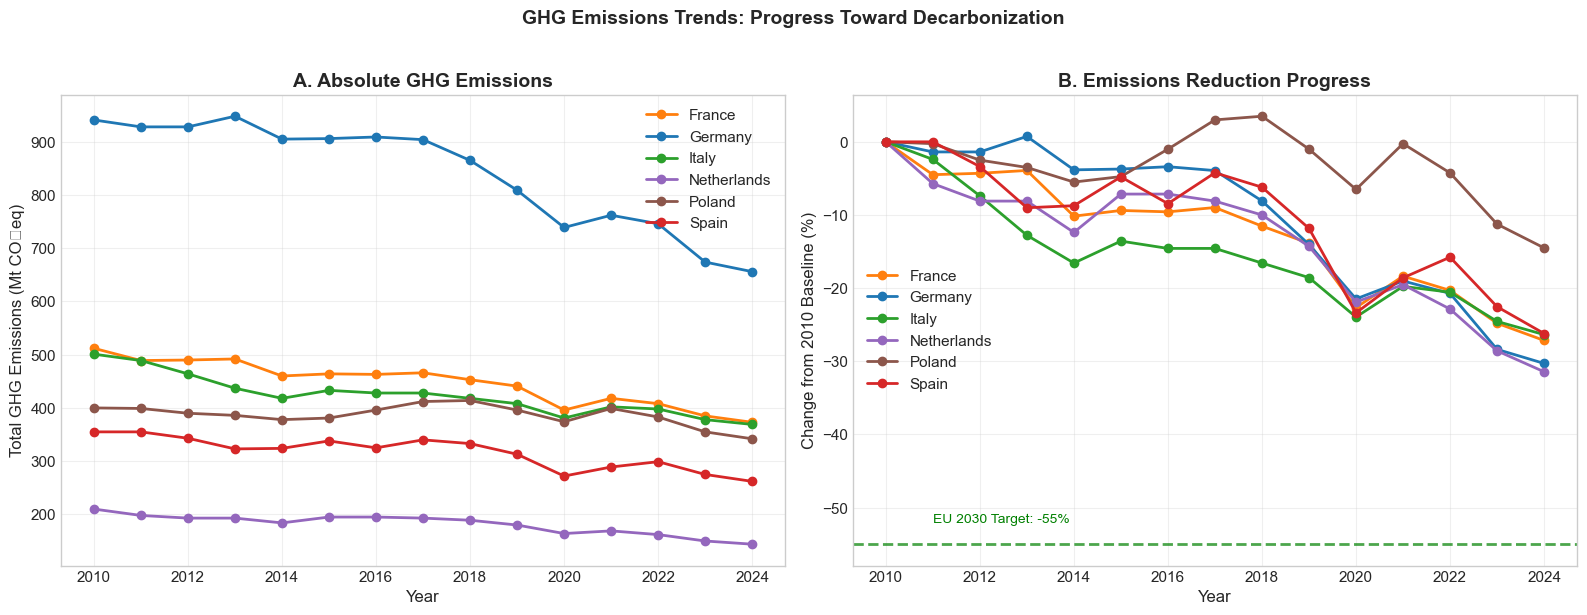


✓ Saved: ../../output/figures/fig3_emissions_trends.png


In [13]:
# Figure 3: GHG Emissions Decline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Absolute emissions
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[0].plot(data['year'], data['total_ghg_mt_co2eq'], 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total GHG Emissions (Mt CO₂eq)')
axes[0].set_title('A. Absolute GHG Emissions', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Panel B: Reduction from 2010 baseline
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[1].plot(data['year'], data['reduction_from_2010_pct'], 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[1].axhline(y=-55, color='green', linestyle='--', linewidth=2, alpha=0.7)
axes[1].text(2011, -52, 'EU 2030 Target: -55%', fontsize=10, color='green')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Change from 2010 Baseline (%)')
axes[1].set_title('B. Emissions Reduction Progress', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

fig.suptitle('GHG Emissions Trends: Progress Toward Decarbonization', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_emissions_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig3_emissions_trends.png'}")

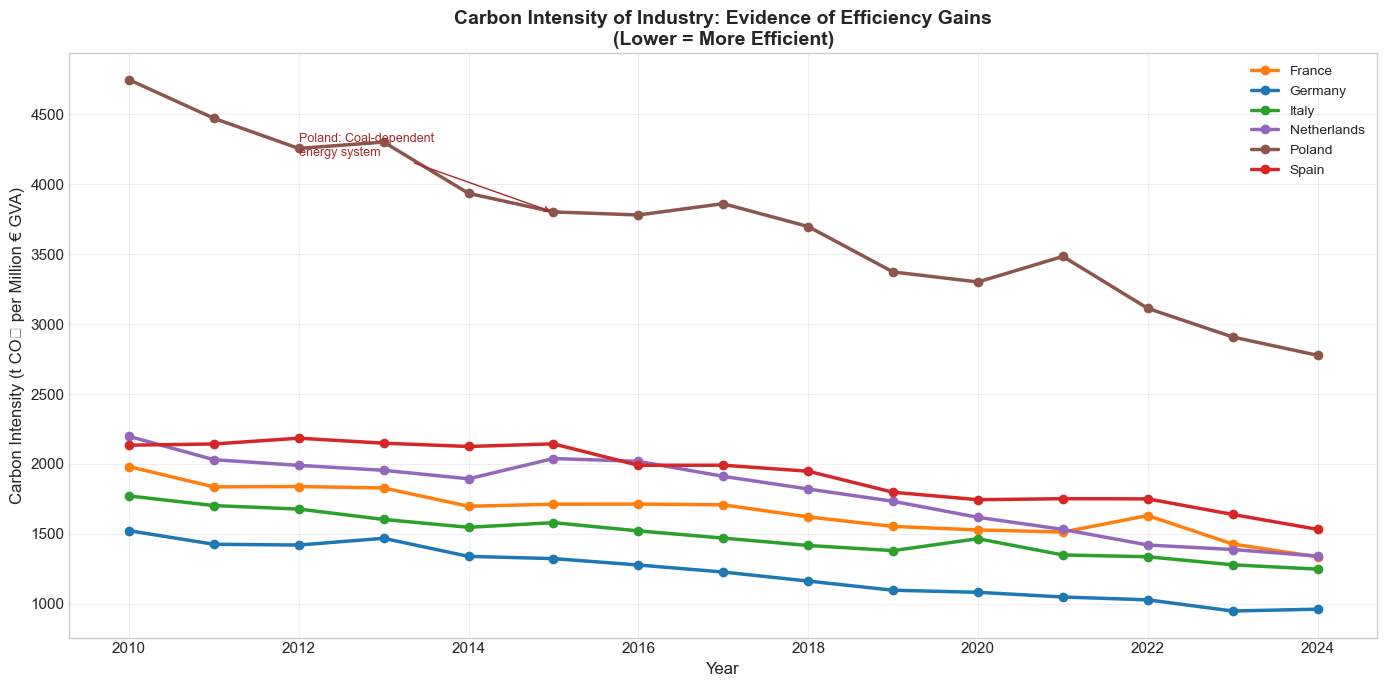


✓ Saved: ../../output/figures/fig4_carbon_intensity.png


In [14]:
# Figure 4: Carbon Intensity Decline (Efficiency Gains)
fig, ax = plt.subplots(figsize=(14, 7))

for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    ax.plot(data['year'], data['carbon_intensity_t_per_meur'], 
            marker='o', linewidth=2.5, label=country, color=COUNTRY_COLORS[country])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Carbon Intensity (t CO₂ per Million € GVA)', fontsize=12)
ax.set_title('Carbon Intensity of Industry: Evidence of Efficiency Gains\n(Lower = More Efficient)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate Poland (highest intensity)
ax.annotate('Poland: Coal-dependent\nenergy system', xy=(2015, 3800), xytext=(2012, 4200),
            arrowprops=dict(arrowstyle='->', color='brown'), fontsize=9, color='brown')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_carbon_intensity.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig4_carbon_intensity.png'}")

## 4. The "Decoupling" Question: GDP vs Emissions

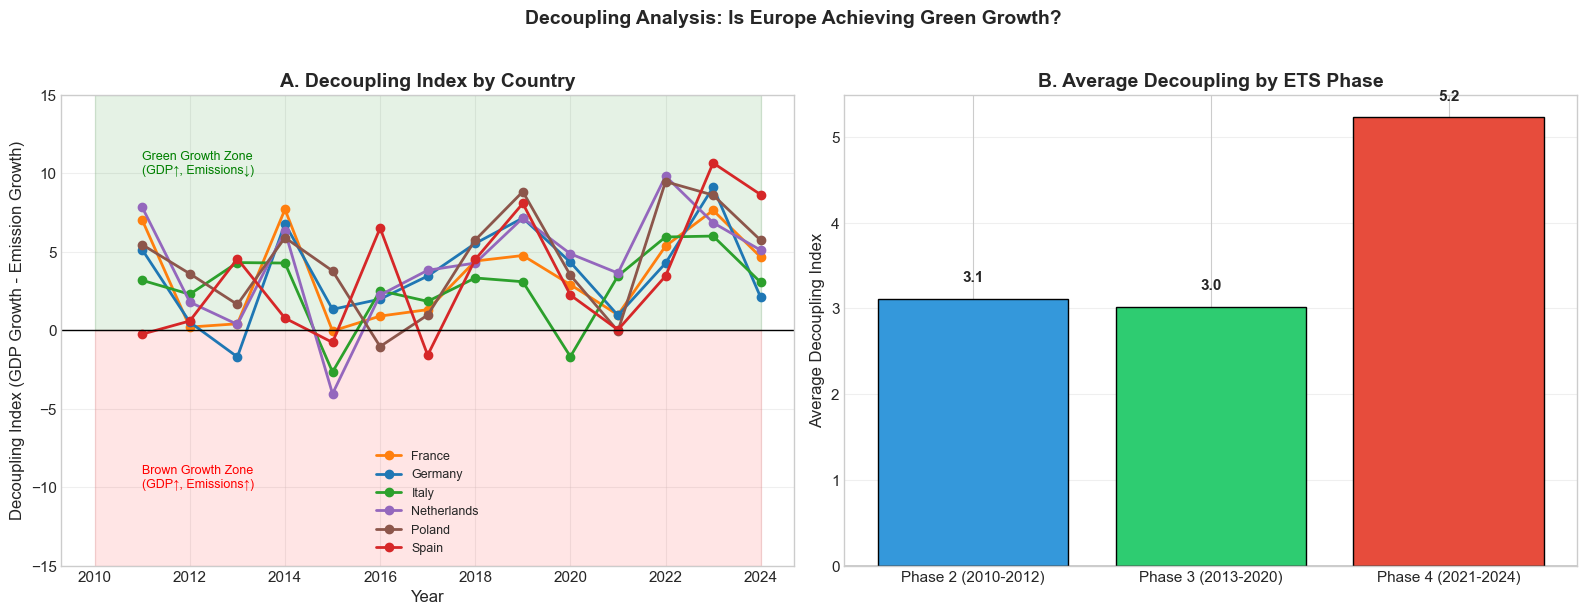


✓ Saved: ../../output/figures/fig5_decoupling_analysis.png


In [15]:
# Figure 5: Decoupling Index Over Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Decoupling index by country
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country].dropna(subset=['decoupling_index'])
    axes[0].plot(data['year'], data['decoupling_index'], 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0].fill_between([2010, 2024], 0, 15, alpha=0.1, color='green')
axes[0].fill_between([2010, 2024], 0, -15, alpha=0.1, color='red')
axes[0].text(2011, 10, 'Green Growth Zone\n(GDP↑, Emissions↓)', fontsize=9, color='green')
axes[0].text(2011, -10, 'Brown Growth Zone\n(GDP↑, Emissions↑)', fontsize=9, color='red')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Decoupling Index (GDP Growth - Emission Growth)')
axes[0].set_title('A. Decoupling Index by Country', fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-15, 15)

# Panel B: Average decoupling by ETS phase
phase_decoupling = df.groupby('ets_phase_label')['decoupling_index'].mean()
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[1].bar(phase_decoupling.index, phase_decoupling.values, color=colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_ylabel('Average Decoupling Index')
axes[1].set_title('B. Average Decoupling by ETS Phase', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, phase_decoupling.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Decoupling Analysis: Is Europe Achieving Green Growth?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_decoupling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig5_decoupling_analysis.png'}")

## 5. Carbon Cost Burden Analysis

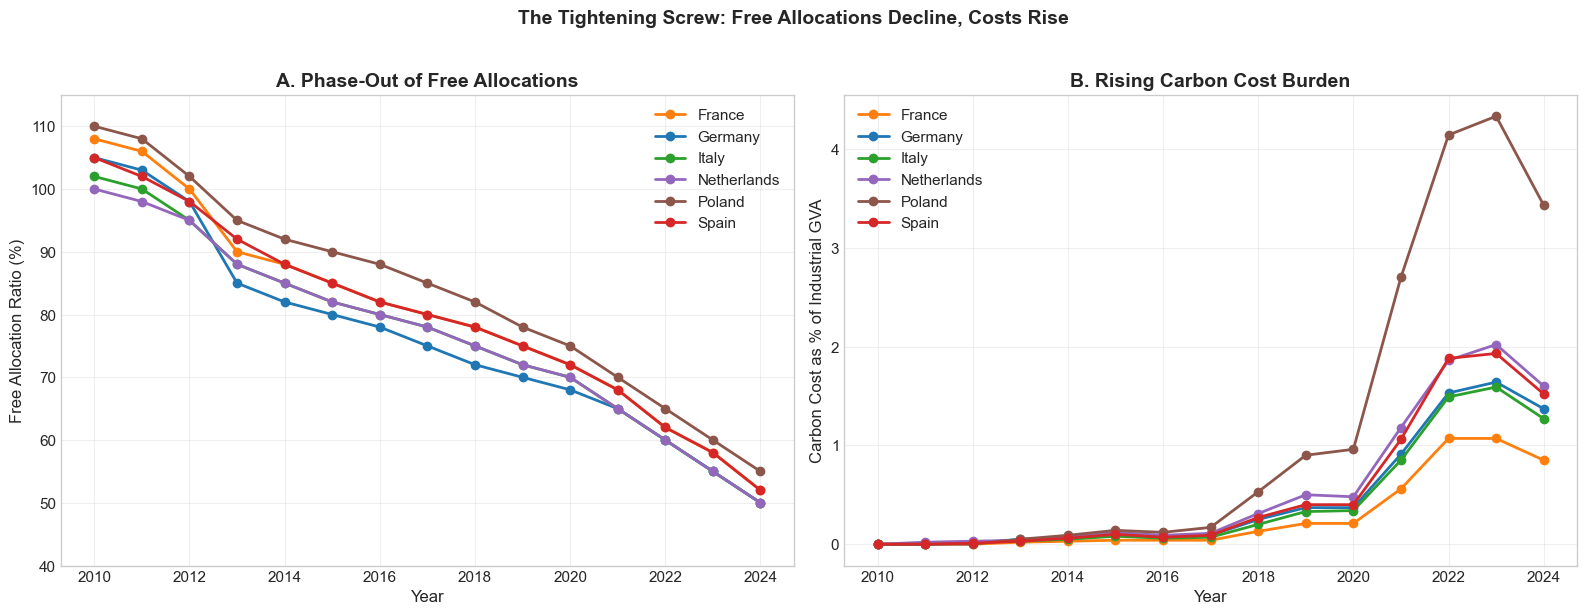


✓ Saved: ../../output/figures/fig6_carbon_cost_burden.png


In [16]:
# Figure 6: Free Allocation Phase-Out and Cost Burden
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Free allocation ratio declining
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[0].plot(data['year'], data['free_allocation_ratio_pct'], 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Free Allocation Ratio (%)')
axes[0].set_title('A. Phase-Out of Free Allocations', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(40, 115)

# Panel B: Carbon cost burden rising
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[1].plot(data['year'], data['carbon_cost_burden_pct'], 
                 marker='o', linewidth=2, label=country, color=COUNTRY_COLORS[country])

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Carbon Cost as % of Industrial GVA')
axes[1].set_title('B. Rising Carbon Cost Burden', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

fig.suptitle('The Tightening Screw: Free Allocations Decline, Costs Rise', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_carbon_cost_burden.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n Saved: {OUTPUT_DIR / 'fig6_carbon_cost_burden.png'}")

## 6. Correlation Analysis

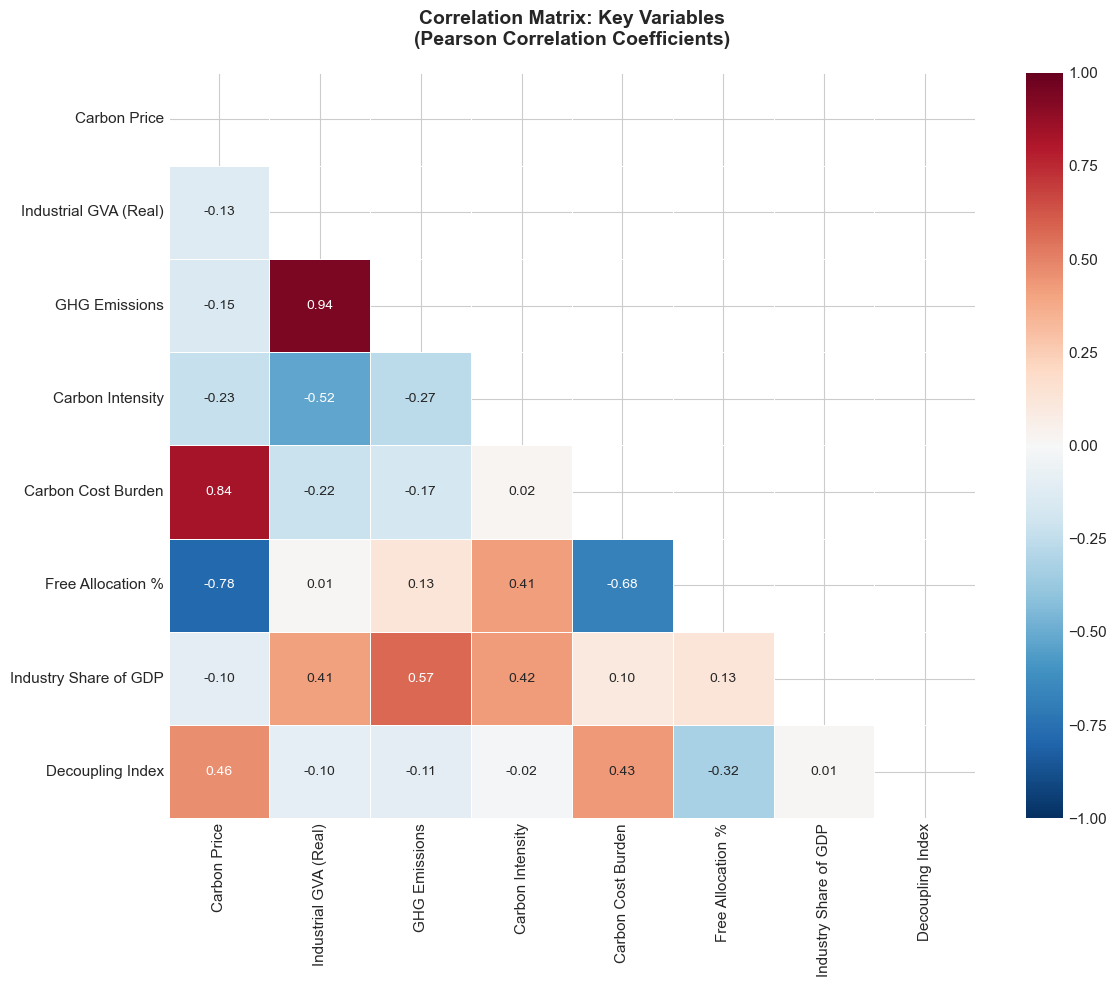


✓ Saved: ../../output/figures/fig7_correlation_heatmap.png


In [17]:
# Select variables for correlation analysis
corr_vars = [
    'carbon_price_eur_tonne',
    'gva_industry_real_meur',
    'total_ghg_mt_co2eq',
    'carbon_intensity_t_per_meur',
    'carbon_cost_burden_pct',
    'free_allocation_ratio_pct',
    'industry_share_pct',
    'decoupling_index'
]

# Rename for clarity
corr_labels = {
    'carbon_price_eur_tonne': 'Carbon Price',
    'gva_industry_real_meur': 'Industrial GVA (Real)',
    'total_ghg_mt_co2eq': 'GHG Emissions',
    'carbon_intensity_t_per_meur': 'Carbon Intensity',
    'carbon_cost_burden_pct': 'Carbon Cost Burden',
    'free_allocation_ratio_pct': 'Free Allocation %',
    'industry_share_pct': 'Industry Share of GDP',
    'decoupling_index': 'Decoupling Index'
}

corr_df = df[corr_vars].rename(columns=corr_labels)
correlation_matrix = corr_df.corr()

# Figure 7: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, linewidths=0.5,
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'fontsize': 10})
ax.set_title('Correlation Matrix: Key Variables\n(Pearson Correlation Coefficients)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig7_correlation_heatmap.png'}")

In [18]:
# Key correlations interpretation
print("\nKEY CORRELATIONS INTERPRETATION")
print("="*70)
print(f"\n1. Carbon Price ↔ GHG Emissions: r = {correlation_matrix.loc['Carbon Price', 'GHG Emissions']:.3f}")
print("   → Negative correlation suggests higher prices associated with lower emissions")

print(f"\n2. Carbon Price ↔ Industrial GVA: r = {correlation_matrix.loc['Carbon Price', 'Industrial GVA (Real)']:.3f}")
print("   → Sign indicates relationship between carbon pricing and industrial output")

print(f"\n3. Carbon Price ↔ Carbon Intensity: r = {correlation_matrix.loc['Carbon Price', 'Carbon Intensity']:.3f}")
print("   → Negative correlation suggests efficiency improvements with higher prices")

print(f"\n4. Free Allocation ↔ Carbon Cost Burden: r = {correlation_matrix.loc['Free Allocation %', 'Carbon Cost Burden']:.3f}")
print("   → Shows how free allocations shield industry from costs")


KEY CORRELATIONS INTERPRETATION

1. Carbon Price ↔ GHG Emissions: r = -0.153
   → Negative correlation suggests higher prices associated with lower emissions

2. Carbon Price ↔ Industrial GVA: r = -0.126
   → Sign indicates relationship between carbon pricing and industrial output

3. Carbon Price ↔ Carbon Intensity: r = -0.233
   → Negative correlation suggests efficiency improvements with higher prices

4. Free Allocation ↔ Carbon Cost Burden: r = -0.679
   → Shows how free allocations shield industry from costs


## 7. Scatter Plot Analysis: Key Relationships

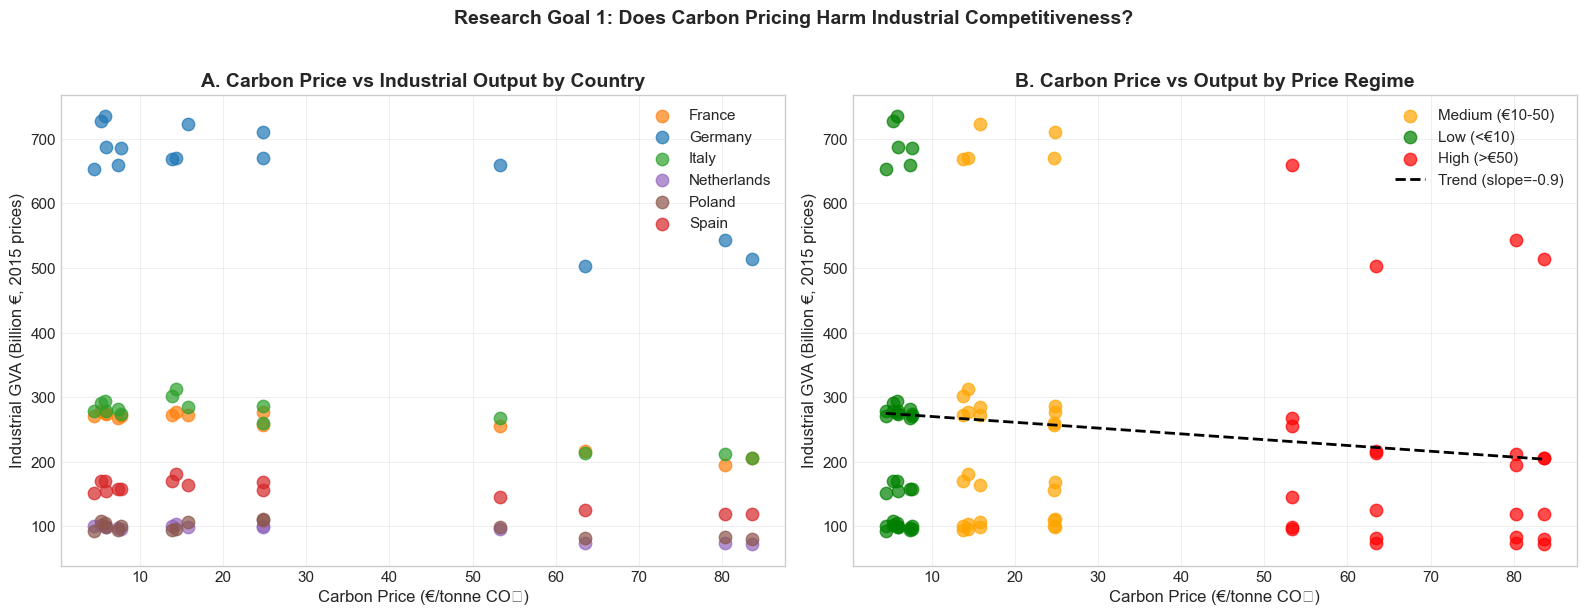


✓ Saved: ../../output/figures/fig8_carbon_price_vs_output.png


In [19]:
# Figure 8: Carbon Price vs Industrial Output
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Scatter by country
for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    axes[0].scatter(data['carbon_price_eur_tonne'], data['gva_industry_real_meur']/1000, 
                    label=country, s=80, alpha=0.7, color=COUNTRY_COLORS[country])

axes[0].set_xlabel('Carbon Price (€/tonne CO₂)')
axes[0].set_ylabel('Industrial GVA (Billion €, 2015 prices)')
axes[0].set_title('A. Carbon Price vs Industrial Output by Country', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Panel B: Scatter by price regime with regression line
colors_regime = {'Low (<€10)': 'green', 'Medium (€10-50)': 'orange', 'High (>€50)': 'red'}
for regime in df['price_regime'].unique():
    data = df[df['price_regime'] == regime]
    axes[1].scatter(data['carbon_price_eur_tonne'], data['gva_industry_real_meur']/1000, 
                    label=regime, s=80, alpha=0.7, color=colors_regime.get(regime, 'gray'))

# Add overall trend line
x = df['carbon_price_eur_tonne']
y = df['gva_industry_real_meur']/1000
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[1].plot(sorted(x), p(sorted(x)), 'k--', linewidth=2, label=f'Trend (slope={z[0]:.1f})')

axes[1].set_xlabel('Carbon Price (€/tonne CO₂)')
axes[1].set_ylabel('Industrial GVA (Billion €, 2015 prices)')
axes[1].set_title('B. Carbon Price vs Output by Price Regime', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Research Goal 1: Does Carbon Pricing Harm Industrial Competitiveness?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig8_carbon_price_vs_output.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig8_carbon_price_vs_output.png'}")

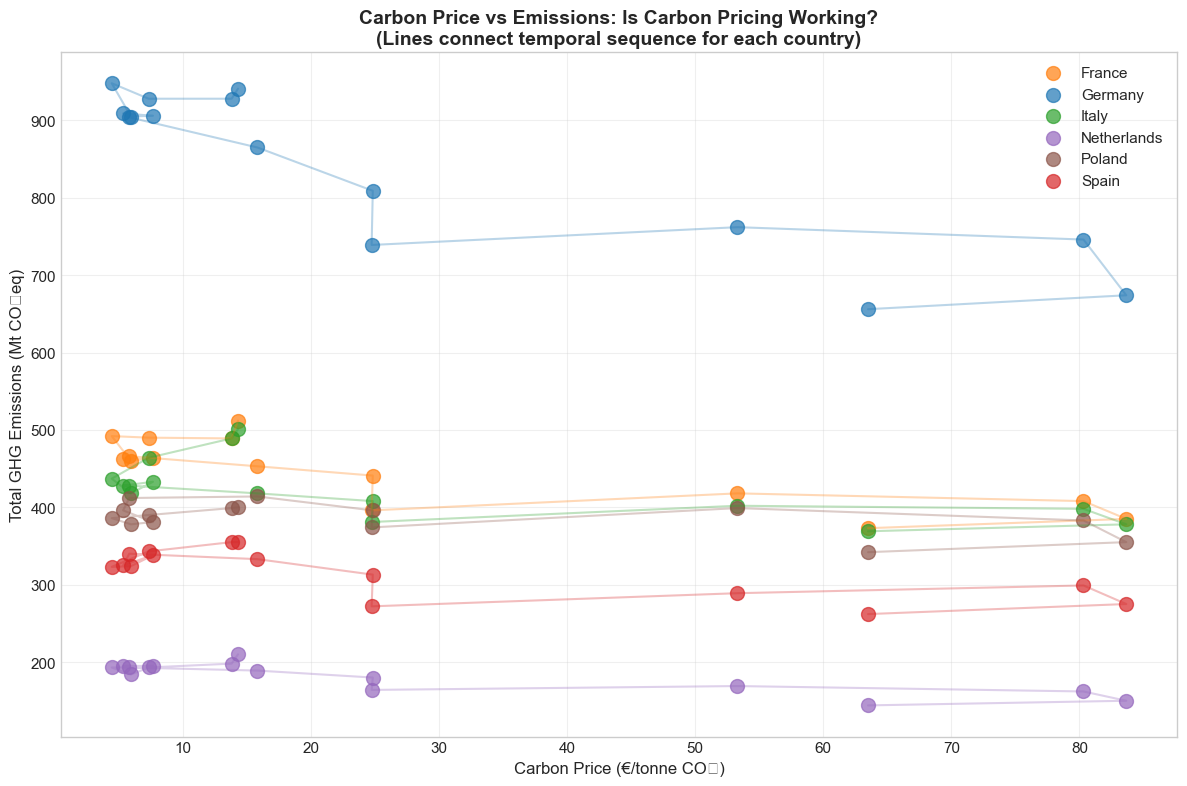


✓ Saved: ../../output/figures/fig9_carbon_price_vs_emissions.png


In [20]:
# Figure 9: Carbon Price vs Emissions (Direct Effect)
fig, ax = plt.subplots(figsize=(12, 8))

for country in sorted(df['country'].unique()):
    data = df[df['country'] == country]
    ax.scatter(data['carbon_price_eur_tonne'], data['total_ghg_mt_co2eq'], 
               label=country, s=100, alpha=0.7, color=COUNTRY_COLORS[country])
    
    # Connect points with lines to show trajectory
    ax.plot(data['carbon_price_eur_tonne'], data['total_ghg_mt_co2eq'], 
            alpha=0.3, color=COUNTRY_COLORS[country])

ax.set_xlabel('Carbon Price (€/tonne CO₂)', fontsize=12)
ax.set_ylabel('Total GHG Emissions (Mt CO₂eq)', fontsize=12)
ax.set_title('Carbon Price vs Emissions: Is Carbon Pricing Working?\n(Lines connect temporal sequence for each country)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig9_carbon_price_vs_emissions.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig9_carbon_price_vs_emissions.png'}")

## 8. The "Valley of Death" Analysis (2021-2024)

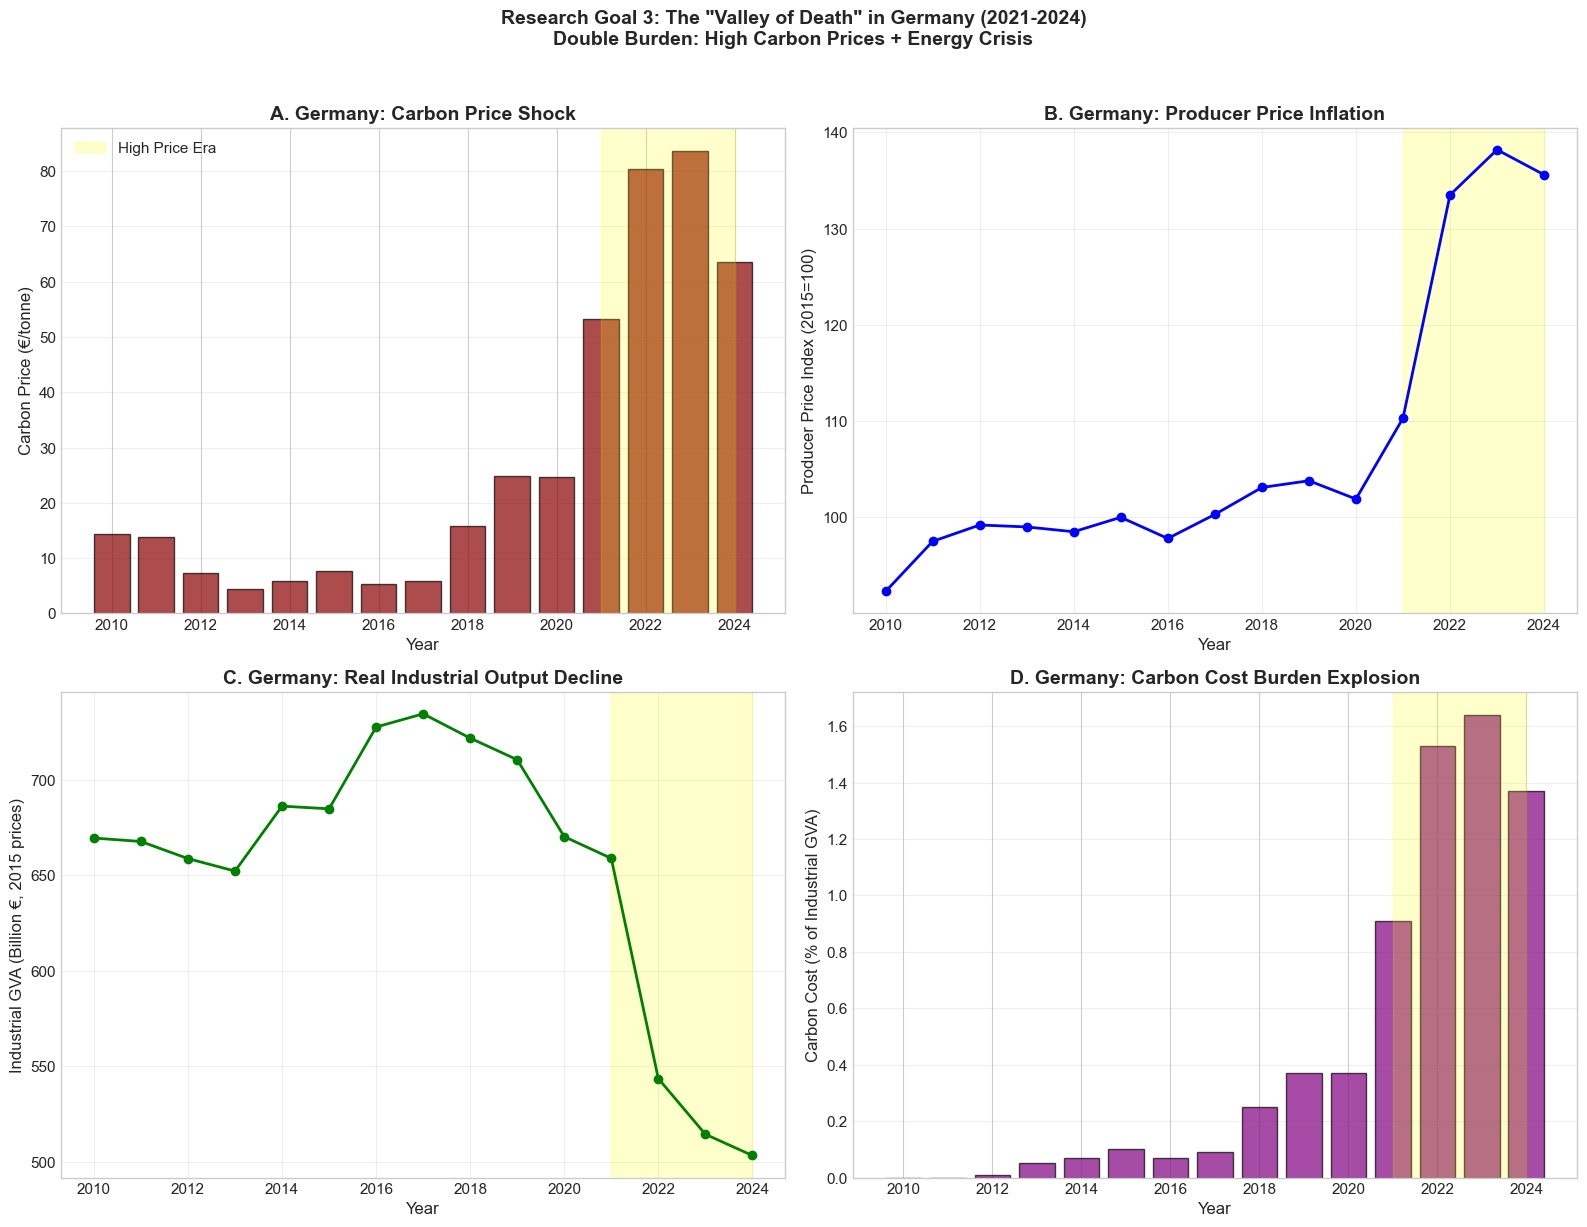


✓ Saved: ../../output/figures/fig10_valley_of_death_germany.png


In [21]:
# Figure 10: The Double Burden - Carbon Price + Energy Crisis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get Germany as case study (largest economy)
de = df[df['country'] == 'Germany'].copy()

# Panel A: Carbon price spike
ax = axes[0, 0]
ax.bar(de['year'], de['carbon_price_eur_tonne'], color='darkred', alpha=0.7, edgecolor='black')
ax.axvspan(2021, 2024, alpha=0.2, color='yellow', label='High Price Era')
ax.set_xlabel('Year')
ax.set_ylabel('Carbon Price (€/tonne)')
ax.set_title('A. Germany: Carbon Price Shock', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Panel B: PPI inflation
ax = axes[0, 1]
ax.plot(de['year'], de['ppi_index_2015'], marker='o', linewidth=2, color='blue')
ax.axvspan(2021, 2024, alpha=0.2, color='yellow')
ax.set_xlabel('Year')
ax.set_ylabel('Producer Price Index (2015=100)')
ax.set_title('B. Germany: Producer Price Inflation', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel C: Real industrial output decline
ax = axes[1, 0]
ax.plot(de['year'], de['gva_industry_real_meur']/1000, marker='o', linewidth=2, color='green')
ax.axvspan(2021, 2024, alpha=0.2, color='yellow')
ax.set_xlabel('Year')
ax.set_ylabel('Industrial GVA (Billion €, 2015 prices)')
ax.set_title('C. Germany: Real Industrial Output Decline', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel D: Carbon cost burden explosion
ax = axes[1, 1]
ax.bar(de['year'], de['carbon_cost_burden_pct'], color='purple', alpha=0.7, edgecolor='black')
ax.axvspan(2021, 2024, alpha=0.2, color='yellow')
ax.set_xlabel('Year')
ax.set_ylabel('Carbon Cost (% of Industrial GVA)')
ax.set_title('D. Germany: Carbon Cost Burden Explosion', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Research Goal 3: The "Valley of Death" in Germany (2021-2024)\nDouble Burden: High Carbon Prices + Energy Crisis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig10_valley_of_death_germany.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig10_valley_of_death_germany.png'}")

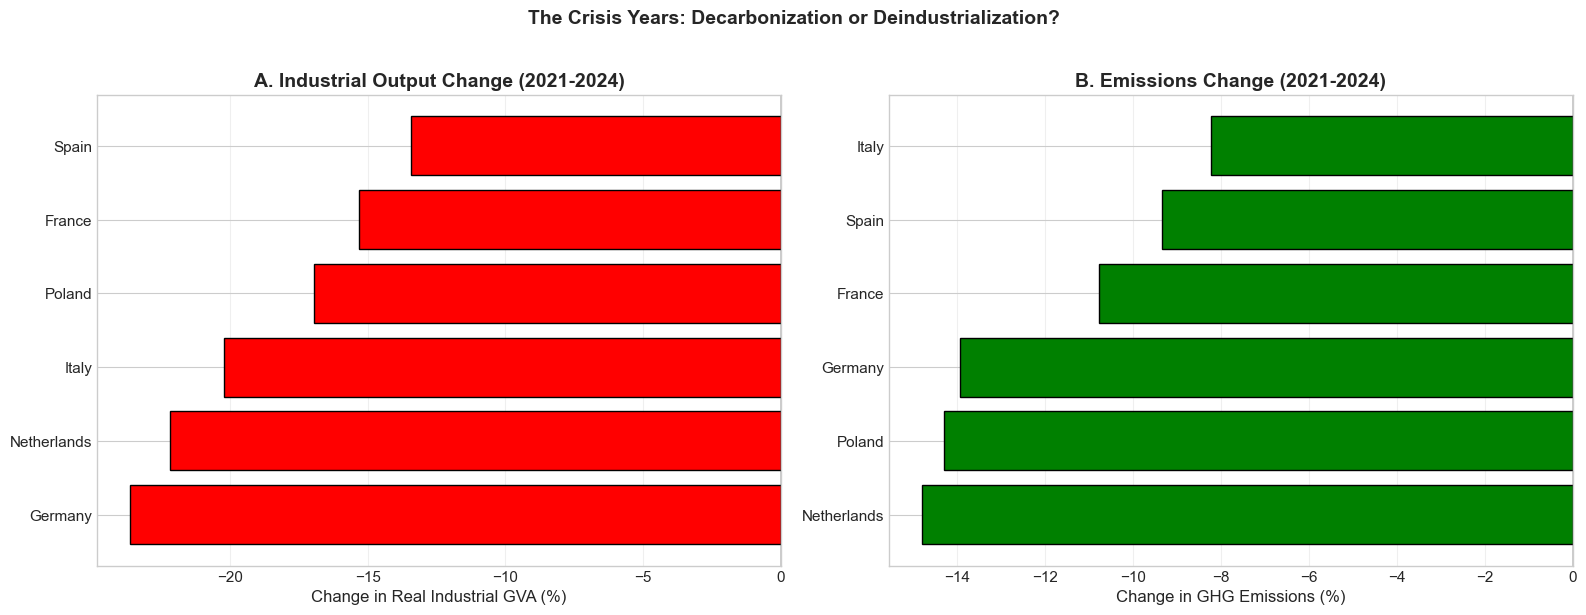


✓ Saved: ../../output/figures/fig11_crisis_comparison.png


In [22]:
# Figure 11: Cross-Country Comparison During Crisis (2021-2024)
crisis_period = df[df['year'] >= 2021].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Industrial output change 2021-2024
output_change = df.pivot_table(index='country', columns='year', values='gva_industry_real_meur')
output_change['change_pct'] = ((output_change[2024] - output_change[2021]) / output_change[2021] * 100)
output_change = output_change.sort_values('change_pct')

colors = ['red' if x < 0 else 'green' for x in output_change['change_pct']]
axes[0].barh(output_change.index, output_change['change_pct'], color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Change in Real Industrial GVA (%)')
axes[0].set_title('A. Industrial Output Change (2021-2024)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Panel B: Emissions reduction during crisis
emissions_change = df.pivot_table(index='country', columns='year', values='total_ghg_mt_co2eq')
emissions_change['change_pct'] = ((emissions_change[2024] - emissions_change[2021]) / emissions_change[2021] * 100)
emissions_change = emissions_change.sort_values('change_pct')

colors = ['green' if x < 0 else 'red' for x in emissions_change['change_pct']]  # Green for reduction
axes[1].barh(emissions_change.index, emissions_change['change_pct'], color=colors, edgecolor='black')
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Change in GHG Emissions (%)')
axes[1].set_title('B. Emissions Change (2021-2024)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

fig.suptitle('The Crisis Years: Decarbonization or Deindustrialization?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig11_crisis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig11_crisis_comparison.png'}")

## 9. Summary Statistics Table

In [23]:
# Create publication-ready summary table
print("\n" + "="*80)
print("SUMMARY STATISTICS BY ETS PHASE")
print("="*80)

summary_vars = [
    'carbon_price_eur_tonne',
    'gva_industry_real_meur',
    'total_ghg_mt_co2eq',
    'carbon_intensity_t_per_meur',
    'carbon_cost_burden_pct',
    'free_allocation_ratio_pct',
    'decoupling_index'
]

summary_labels = {
    'carbon_price_eur_tonne': 'Carbon Price (€/tonne)',
    'gva_industry_real_meur': 'Industrial GVA (M€, real)',
    'total_ghg_mt_co2eq': 'GHG Emissions (Mt CO₂eq)',
    'carbon_intensity_t_per_meur': 'Carbon Intensity (t/M€)',
    'carbon_cost_burden_pct': 'Carbon Cost Burden (%)',
    'free_allocation_ratio_pct': 'Free Allocation (%)',
    'decoupling_index': 'Decoupling Index'
}

summary = df.groupby('ets_phase_label')[summary_vars].agg(['mean', 'std']).round(2)
summary.columns = [f'{summary_labels[col]}_{stat}' for col, stat in summary.columns]
summary


SUMMARY STATISTICS BY ETS PHASE


,Carbon Price (€/tonne)_mean,Carbon Price (€/tonne)_std,"Industrial GVA (M€, real)_mean","Industrial GVA (M€, real)_std",GHG Emissions (Mt CO₂eq)_mean,GHG Emissions (Mt CO₂eq)_std,Carbon Intensity (t/M€)_mean,Carbon Intensity (t/M€)_std,Carbon Cost Burden (%)_mean,Carbon Cost Burden (%)_std,Free Allocation (%)_mean,Free Allocation (%)_std,Decoupling Index_mean,Decoupling Index_std
ets_phase_label,,,,,,,,,,,,,,
Phase 2 (2010-2012),11.83,3.27,266920.66,199974.58,476.94,232.84,2296.31,1042.72,0.00,0.01,101.94,4.40,3.11,2.74
Phase 3 (2013-2020),11.84,8.27,269510.90,207434.29,441.02,216.18,2005.39,844.11,0.19,0.21,80.35,6.75,3.02,3.00
Phase 4 (2021-2024),70.20,12.65,215296.73,168487.66,383.25,173.00,1656.00,691.35,1.74,0.98,59.17,6.10,5.23,3.18


In [ ]:
# Save summary table
summary.to_csv(OUTPUT_DIR / 'table1_summary_by_phase.csv')
print(f"\n✓ Saved: {OUTPUT_DIR / 'table1_summary_by_phase.csv'}")

## 10. Key EDA Findings

### Summary of Exploratory Findings:

**1. Carbon Price Evolution:**
- EU ETS prices collapsed to ~€5/tonne during 2013-2017 (Phase 3 early years)
- MSR activation (2019) triggered price recovery
- Phase 4 (2021+) saw prices surge to €80+/tonne

**2. Emissions Trends:**
- All six countries show declining emissions from 2010 baseline
- Reductions range from ~15% to ~30% by 2024
- COVID-19 caused temporary acceleration (2020)

**3. Industrial Output:**
- Real (inflation-adjusted) GVA shows stagnation in 2022-2024
- Germany and France show clear output decline in high-price era
- Poland shows relative resilience despite high carbon intensity

**4. Carbon Intensity:**
- Declining across all countries (efficiency gains)
- Poland remains 2-3x more carbon-intensive than Western Europe
- Convergence pattern visible (catch-up effect)

**5. Decoupling:**
- Positive decoupling index in most years (green growth)
- Higher decoupling during Phase 4 (high price era)
- Question: Is this true efficiency or industrial decline?

**6. Carbon Cost Burden:**
- Phase-out of free allocations is accelerating
- Carbon cost burden rose from ~0% to 1-4% of GVA
- Poland faces highest burden due to coal dependence
